# Part1.5 SHAP ANALYSIS OF SCORES

## Objective

To understand which variables most strongly influence each country’s:

- Efficiency Score – output per unit of environmental input
- Sustainability Score – output adjusted for environmental pressure

We used SHAP (SHapley Additive exPlanations) to quantify the contribution of each variable to the model outputs, improving interpretability of the composite scores.


In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [203]:
df_structure = pd.read_csv("structure_all_combined.csv")
df_structure = df_structure[['country', 'year', 'crop_ratio']].copy()
df_structure

,country,year,crop_ratio
0,A2,1990,0.827857
1,A2,1991,0.820879
2,A2,1992,0.838498
3,A2,1993,0.812873
4,A2,1994,0.842892
...,...,...,...
1881,ZAF,2026,0.874492
1882,ZAF,2027,0.875454
1883,ZAF,2028,0.876603
1884,ZAF,2029,0.877952


In [204]:
df_policy = pd.read_csv("policy_all_combined.csv")
df_policy

,country,year,PSEP,CSE,GSSE
0,ARG,1986,0.0000,NaN,0.0000
1,ARG,1987,0.0000,NaN,0.0000
2,ARG,1988,0.0000,NaN,0.0000
3,ARG,1989,0.0000,NaN,0.0000
4,ARG,1990,0.0000,NaN,0.0000
...,...,...,...,...,...
945,ZAF,2019,2.9042,-2532.824800,306.4453
946,ZAF,2020,3.5655,-2601.280900,300.6648
947,ZAF,2021,2.5002,-1980.531533,322.6296
948,ZAF,2022,3.1936,-3603.546500,270.9124


In [207]:
df_full = pd.merge(df_structure, df_policy, on=['country', 'year'], how='inner')
df_full

,country,year,crop_ratio,PSEP,CSE,GSSE
0,ARG,1990,0.881692,0.0000,NaN,0.0000
1,ARG,1991,0.891115,0.0000,NaN,0.0000
2,ARG,1992,0.886780,0.0000,NaN,0.0000
3,ARG,1993,0.880320,0.0000,NaN,0.0000
4,ARG,1994,0.881679,0.0000,NaN,0.0000
...,...,...,...,...,...,...
845,ZAF,2019,0.866262,2.9042,-2532.824800,306.4453
846,ZAF,2020,0.870476,3.5655,-2601.280900,300.6648
847,ZAF,2021,0.870815,2.5002,-1980.531533,322.6296
848,ZAF,2022,0.871510,3.1936,-3603.546500,270.9124


In [209]:
df_eff = pd.read_csv("scores_updated.csv")
df_eff = df_eff[['Country', 'Year', 'efficiency_score', 'sustainability_score']].copy()
df_eff

,Country,Year,efficiency_score,sustainability_score
0,Argentina,2012,0.077906,0.076689
1,Argentina,2013,0.073584,0.074357
2,Argentina,2014,0.074842,0.076701
3,Argentina,2015,0.053776,0.083798
4,Argentina,2016,0.056512,0.087020
...,...,...,...,...
175,United States,2016,0.019808,0.059425
176,United States,2017,0.019797,0.096946
177,United States,2018,0.019715,0.096627
178,United States,2019,0.019805,0.098789


In [210]:
# Create abbreviation and full name mapping
abbr_to_full = {
    'ARG': 'Argentina',
    'AUS': 'Australia',
    'BRA': 'Brazil',
    'CAN': 'Canada',
    'CHE': 'Switzerland',
    'CHL': 'Chile',
    'CHN': 'China (People’s Republic of)',
    'COL': 'Colombia',
    'GBR': 'United Kingdom',
    'IDN': 'Indonesia',
    'IND': 'India',
    'ISR': 'Israel',
    'JPN': 'Japan',
    'KAZ': 'Kazakhstan',
    'KOR': 'Korea',
    'MEX': 'Mexico',
    'NOR': 'Norway',
    'NZL': 'New Zealand',
    'PHL': 'Philippines',
    'RUS': 'Russia',
    'TUR': 'Türkiye',
    'UKR': 'Ukraine',
    'USA': 'United States',
    'VNM': 'Viet Nam',
    'ZAF': 'South Africa'
}

df_full.rename(columns={'year': 'Year', 'country': 'Country'}, inplace=True)
df_full['Country'] = df_full['Country'].map(abbr_to_full)
df_full

,Country,Year,crop_ratio,PSEP,CSE,GSSE
0,Argentina,1990,0.881692,0.0000,NaN,0.0000
1,Argentina,1991,0.891115,0.0000,NaN,0.0000
2,Argentina,1992,0.886780,0.0000,NaN,0.0000
3,Argentina,1993,0.880320,0.0000,NaN,0.0000
4,Argentina,1994,0.881679,0.0000,NaN,0.0000
...,...,...,...,...,...,...
845,South Africa,2019,0.866262,2.9042,-2532.824800,306.4453
846,South Africa,2020,0.870476,3.5655,-2601.280900,300.6648
847,South Africa,2021,0.870815,2.5002,-1980.531533,322.6296
848,South Africa,2022,0.871510,3.1936,-3603.546500,270.9124


In [211]:
print("eff Country scope:", df_eff['Year'].unique())
print("full Country scope:", df_full['Year'].unique())
print("eff Country scope:", df_eff['Country'].unique())
print("full Country scope:", df_full['Country'].unique())


eff Country scope: [2012 2013 2014 2015 2016 2017 2018 2019 2020]
full Country scope: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023]
eff Country scope: ['Argentina' 'Australia' 'Brazil' 'Canada' 'China (People’s Republic of)'
 'Colombia' 'India' 'Indonesia' 'Japan' 'Kazakhstan' 'Korea' 'Mexico'
 'New Zealand' 'Norway' 'Russia' 'South Africa' 'Switzerland' 'Türkiye'
 'Ukraine' 'United States']
full Country scope: ['Argentina' 'Australia' 'Brazil' 'Canada' 'Switzerland' 'Chile'
 'China (People’s Republic of)' 'Colombia' 'United Kingdom' 'Indonesia'
 'India' 'Israel' 'Japan' 'Kazakhstan' 'Korea' 'Mexico' 'Norway'
 'New Zealand' 'Philippines' 'Russia' 'Türkiye' 'Ukraine' 'United States'
 'Viet Nam' 'South Africa']


In [212]:
merged_df = pd.merge(df_eff, df_full, on=['Country', 'Year'], how='left')
merged_df

,Country,Year,efficiency_score,sustainability_score,crop_ratio,PSEP,CSE,GSSE
0,Argentina,2012,0.077906,0.076689,0.918572,-23.4396,6146.934367,661.9508
1,Argentina,2013,0.073584,0.074357,0.925098,-31.4168,13488.441667,706.0072
2,Argentina,2014,0.074842,0.076701,0.932033,-37.6689,20479.428300,627.7144
3,Argentina,2015,0.053776,0.083798,0.926523,-29.2427,18117.483267,748.9670
4,Argentina,2016,0.056512,0.087020,0.939160,-12.9209,6234.594100,535.1169
...,...,...,...,...,...,...,...,...
175,United States,2016,0.019808,0.059425,0.848071,8.6295,37164.356533,9908.4608
176,United States,2017,0.019797,0.096946,0.842008,6.6360,38434.713567,10638.4120
177,United States,2018,0.019715,0.096627,0.840537,9.3686,39416.513400,10896.3020
178,United States,2019,0.019805,0.098789,0.830666,10.2018,38809.278900,11216.2180


In [213]:
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               180 non-null    object 
 1   Year                  180 non-null    int64  
 2   efficiency_score      180 non-null    float64
 3   sustainability_score  180 non-null    float64
 4   crop_ratio            180 non-null    float64
 5   PSEP                  180 non-null    float64
 6   CSE                   180 non-null    float64
 7   GSSE                  180 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 11.4+ KB
None


## Variable Descriptions

- **`Crop Ratio`**  
  Defined as `crop / (crop + livestock)`, this variable captures the structural orientation of a country's agriculture. A higher value indicates a crop-dominant system, while a lower value suggests a livestock-heavy system.

- **`PSEP`** (*Producer Support Estimate, Percentage*):  
  Represents the share of direct governmental support provided to agricultural producers. It reflects how much farmers are incentivized via subsidies or market interventions.

- **`GSSE`** (*General Services Support Estimate*):  
  Measures government expenditure on general services that benefit the agricultural sector as a whole (e.g., research, extension services, infrastructure), rather than direct payments to producers.

- **`CSE`** (*Consumer Support Estimate*):  
  Represents policies aimed at consumers, such as price controls or subsidies, which can indirectly influence production and consumption patterns.

---

### Efficiency Score

In [215]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt

target = 'efficiency_score'
feature_cols = [col for col in merged_df.columns if col not in ['Country', 'Year', 'efficiency_score', 'sustainability_score']]

X = merged_df[feature_cols].copy()
y = merged_df[target].copy()


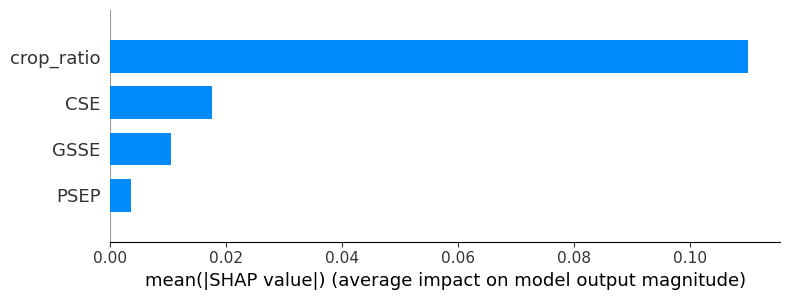

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, plot_type="bar")


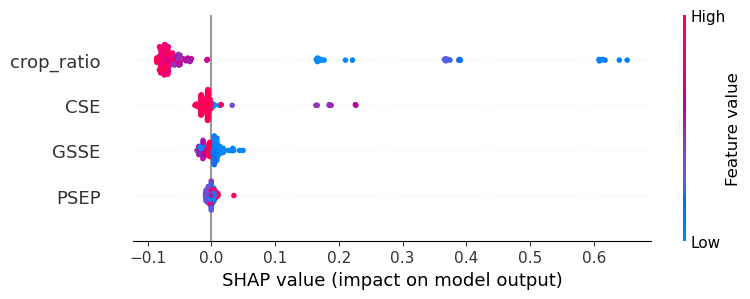

In [217]:
shap.summary_plot(shap_values, X)

In [218]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'variable': X.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

In [219]:
importance_df

,variable,mean_abs_shap
0,crop_ratio,0.109938
2,CSE,0.017553
3,GSSE,0.010453
1,PSEP,0.003523


### Sustainability Score

In [220]:
target = 'sustainability_score'
feature_cols = [col for col in merged_df.columns if col not in ['Country', 'Year', 'efficiency_score', 'sustainability_score']]

X = merged_df[feature_cols].copy()
y = merged_df[target].copy()


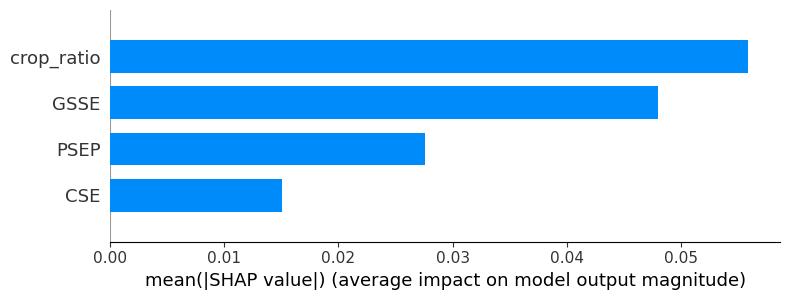

In [221]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, plot_type="bar")


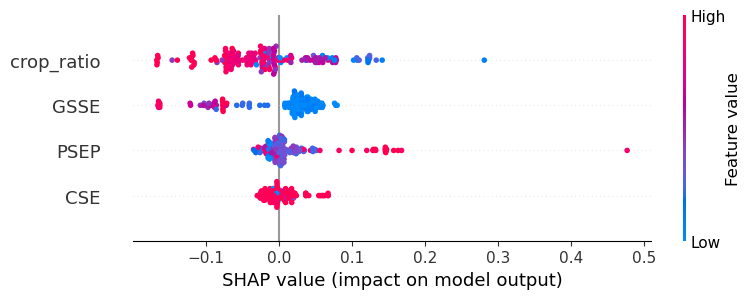

In [222]:
shap.summary_plot(shap_values, X)

In [223]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'variable': X.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

In [224]:
importance_df

,variable,mean_abs_shap
0,crop_ratio,0.055907
3,GSSE,0.047994
1,PSEP,0.027573
2,CSE,0.015053


## SHAP Variable Importance Analysis

###  Efficiency Score
| Variable     | Mean Absolute SHAP Value | Interpretation |
|--------------|---------------------------|----------------|
| `crop_ratio` | **0.110**                 | Strongest driver of efficiency — crop-dominant systems convert inputs into calories more efficiently. |
| `CSE`        | 0.018                     | Consumer-side support may indirectly incentivize more efficient production. |
| `GSSE`       | 0.010                     | General services support contributes marginally to immediate efficiency outcomes. |
| `PSEP`       | 0.0035                    | Minimal influence on efficiency — direct subsidies may not improve productivity. |

###  Sustainability Score
| Variable     | Mean Absolute SHAP Value | Interpretation |
|--------------|---------------------------|----------------|
| `crop_ratio` | **0.056**                 | Crop-heavy systems are associated with lower environmental footprints (e.g., water, GHG, nutrient use). |
| `GSSE`       | 0.048                     | Strong impact — investment in shared infrastructure and R&D reduces environmental pressures. |
| `PSEP`       | 0.028                     | Moderate effect — depends on whether subsidies promote or discourage sustainable practices. |
| `CSE`        | 0.015                     | Weakest influence — consumer-side interventions have limited direct impact on sustainability. |



## Visualization

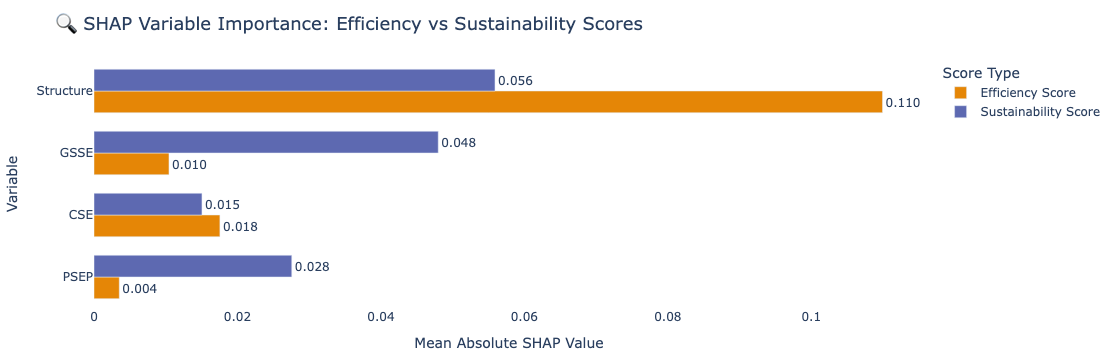

In [229]:
import pandas as pd
import plotly.express as px

# two SHAP importance DataFrames
efficiency_importance = pd.DataFrame({
    'variable': ['Structure', 'CSE', 'GSSE', 'PSEP'],
    'mean_abs_shap': [0.109938, 0.017553, 0.010453, 0.003523]
})

sustainability_importance = pd.DataFrame({
    'variable': ['Structure', 'GSSE', 'PSEP', 'CSE'],
    'mean_abs_shap': [0.055907, 0.047994, 0.027573, 0.015053]
})

# Add tags
efficiency_importance['score_type'] = 'Efficiency Score'
sustainability_importance['score_type'] = 'Sustainability Score'

# Merge data
shap_combined = pd.concat([efficiency_importance, sustainability_importance], ignore_index=True)

# Plotting with Plotly Express
fig = px.bar(
    shap_combined,
    x='mean_abs_shap',
    y='variable',
    color='score_type',
    orientation='h',
    barmode='group',
    text='mean_abs_shap',
    title='🔍 SHAP Variable Importance: Efficiency vs Sustainability Scores',
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(
    xaxis_title='Mean Absolute SHAP Value',
    yaxis_title='Variable',
    legend_title='Score Type',
    title_font_size=18,
    plot_bgcolor='rgba(0,0,0,0)',
    bargap=0.3,
    height=500,
    margin=dict(l=60, r=30, t=60, b=40)
)

fig.update_yaxes(categoryorder='total ascending')
fig.show()


In [230]:
fig.write_html("shap_importance_plot.html")


## Key Findings

- **Crop-dominant systems** (higher `crop_ratio`) tend to outperform livestock-heavy systems in both efficiency and sustainability dimensions.
- **Public investment in general agricultural services (`GSSE`)** significantly enhances sustainability outcomes by reducing resource pressures.
- **Producer support (`PSEP`)** has a small positive or mixed influence, suggesting that not all subsidies lead to efficient or sustainable practices — subsidy design matters.
- **Consumer support (`CSE`)** is more relevant to market behavior than environmental performance.

## Recommendations
- Promote **crop diversification and crop-intensive systems** where agroecologically feasible.
- Prioritize **GSSE funding** — infrastructure, training, R&D — to improve sustainability without compromising output.
- Redesign `PSEP` policies to include **eco-conditionalities**, rewarding sustainable practices.
- Maintain `CSE` transparency and ensure **demand-side incentives** do not indirectly support unsustainable production.
